# Balanced Test Set Evaluation

This notebook evaluates the pre-trained XGBoost Fusion Model on a strictly balanced test set (100 Real videos, 100 Fake videos) using the statically defined optimal threshold of `0.5780`.
This ensures the performance metrics reflect the true discriminative power of the model without the bias of class imbalance.

In [18]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

# 1. Configuration & Paths
OUTPUT_DIR = '/content/drive/MyDrive/Work/DeepFakeg/fusion_artifacts'

X_BALANCED_PATH = os.path.join(OUTPUT_DIR, 'X_test_balanced.npy')
Y_BALANCED_PATH = os.path.join(OUTPUT_DIR, 'y_test_balanced.npy')
MODEL_PATH      = os.path.join(OUTPUT_DIR, 'xgboost_fusion_model.joblib')

# The optimal threshold discovered during tuning
OPTIMAL_THRESHOLD = 0.5780


In [19]:
# 2. Load Data and Model
print("Loading balanced test data...")
X_test_bal = np.load(X_BALANCED_PATH)
y_test_bal = np.load(Y_BALANCED_PATH)

print("Loading XGBoost Fusion model...")
model = joblib.load(MODEL_PATH)

print(f"\nTest Data Shape : {X_test_bal.shape}")
print(f"Class Distribution: {np.bincount(y_test_bal)}")


Loading balanced test data...
Loading XGBoost Fusion model...

Test Data Shape : (200, 2816)
Class Distribution: [100 100]


In [20]:
# 3. Prediction & Evaluation
print(f"\nRunning predictions with threshold = {OPTIMAL_THRESHOLD}...")
y_pred_proba = model.predict_proba(X_test_bal)[:, 1]
y_pred = (y_pred_proba >= OPTIMAL_THRESHOLD).astype(int)

# Calculate Metrics
acc  = accuracy_score(y_test_bal, y_pred)
prec = precision_score(y_test_bal, y_pred)
rec  = recall_score(y_test_bal, y_pred)
f1   = f1_score(y_test_bal, y_pred)
cm   = confusion_matrix(y_test_bal, y_pred)

print("\n" + "="*50)
print(" FINAL BALANCED EVALUATION RESULTS")
print("="*50)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("-"*50)
print("Detailed Classification Report:")
print(classification_report(y_test_bal, y_pred, target_names=['Real (0)', 'Fake (1)']))
print("="*50)



Running predictions with threshold = 0.578...

 FINAL BALANCED EVALUATION RESULTS
Accuracy  : 0.9250
Precision : 0.9474
Recall    : 0.9000
F1-Score  : 0.9231
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.90      0.95      0.93       100
    Fake (1)       0.95      0.90      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200




Saved confusion matrix plot to: /content/drive/MyDrive/Work/DeepFakeg/fusion_artifacts/final_balanced_confusion_matrix.png


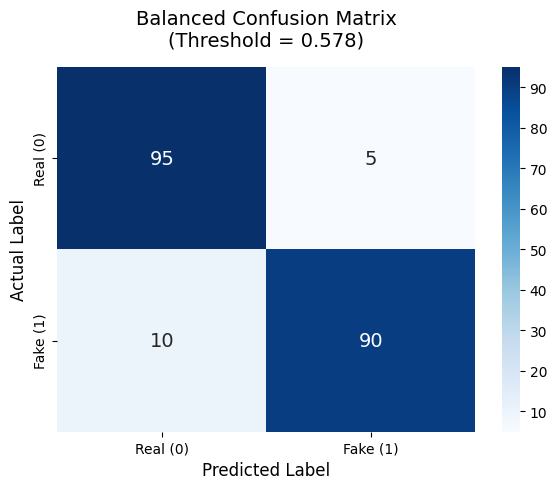

In [21]:
# ==========================================
# 4. Plot Confusion Matrix
# ==========================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'],
            annot_kws={"size": 14})

plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f'Balanced Confusion Matrix\n(Threshold = {OPTIMAL_THRESHOLD})', fontsize=14, pad=15)
plt.tight_layout()

# Save and show
plot_path = os.path.join(OUTPUT_DIR, 'final_balanced_confusion_matrix.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nSaved confusion matrix plot to: {plot_path}")
plt.show()
